In [52]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CẤU HÌNH & CHUẨN BỊ DỮ LIỆU
# ==========================================
# Định nghĩa nhóm
LOW_LEVELS = ['Remember', 'Understand']
HIGH_LEVELS = ['Apply', 'Analyze', 'Evaluate', 'Create']

# Load data
try:
    df = pd.read_csv(r"merged.csv") # Đổi đường dẫn file của bạn
except:
    # Data giả lập để demo code chạy được nếu không có file
    print("⚠️ Đang dùng dữ liệu giả lập để demo...")
    df = pd.DataFrame(np.random.rand(1000, 10), columns=[f'f{i}' for i in range(10)])
    df['Bloom_Label'] = np.random.choice(LOW_LEVELS + HIGH_LEVELS, 1000)

if "id" in df.columns:
    df = df.drop(columns=["id"])

X = df.drop(columns=["Bloom_Label"])
y = df["Bloom_Label"]

# Chia tập Train/Test NGAY TỪ ĐẦU (Giữ nguyên tỉ lệ các nhãn gốc)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Tổng Train: {len(X_train)} | Tổng Test: {len(X_test)}")
# ==========================================
# [THÊM VÀO] KIỂM TRA PHÂN PHỐI MẪU BAN ĐẦU
# ==========================================
def print_class_distribution(y_data, title="Dữ liệu"):
    counts = pd.Series(y_data).value_counts()
    percent = pd.Series(y_data).value_counts(normalize=True) * 100
    df_info = pd.DataFrame({'Số lượng': counts, 'Tỷ lệ (%)': percent.round(2)})
    print(f"\n📊 --- Phân phối {title} ---")
    print(df_info.sort_index()) # Sắp xếp theo tên ABC cho dễ nhìn
    print("-" * 30)

# 1. Xem tổng thể
print_class_distribution(y, "TOÀN BỘ DATASET")

# 2. Xem tập Train và Test
print_class_distribution(y_train, "TẬP TRAIN (80%)")
print_class_distribution(y_test, "TẬP TEST (20%)")
# ==========================================
# 2. HUẤN LUYỆN GIAI ĐOẠN 1: BINARY CLASSIFIER (LOW vs HIGH)
# ==========================================
print("\n🚀 [STAGE 1] Huấn luyện Binary Classifier...")

# Tạo nhãn Binary: 0 = Low, 1 = High
y_train_bin = y_train.apply(lambda x: 0 if x in LOW_LEVELS else 1)
y_test_bin = y_test.apply(lambda x: 0 if x in LOW_LEVELS else 1)

# Model Binary (XGBoost nhẹ)
model_binary = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
model_binary.fit(X_train, y_train_bin)

# Đánh giá nhanh Stage 1
bin_acc = accuracy_score(y_test_bin, model_binary.predict(X_test))
print(f"✅ Độ chính xác phân loại Low/High: {bin_acc:.4f}")


📊 Tổng Train: 2462 | Tổng Test: 616

📊 --- Phân phối TOÀN BỘ DATASET ---
             Số lượng  Tỷ lệ (%)
Bloom_Label                     
Analyze           146       4.74
Apply             126       4.09
Create            263       8.54
Evaluate          106       3.44
Remember          674      21.90
Understand       1763      57.28
------------------------------

📊 --- Phân phối TẬP TRAIN (80%) ---
             Số lượng  Tỷ lệ (%)
Bloom_Label                     
Analyze           117       4.75
Apply             101       4.10
Create            210       8.53
Evaluate           85       3.45
Remember          539      21.89
Understand       1410      57.27
------------------------------

📊 --- Phân phối TẬP TEST (20%) ---
             Số lượng  Tỷ lệ (%)
Bloom_Label                     
Analyze            29       4.71
Apply              25       4.06
Create             53       8.60
Evaluate           21       3.41
Remember          135      21.92
Understand        353      57.31



🔹 [STAGE 2.1] Huấn luyện Low-Level Specialist...
🔸 [STAGE 2.2] Huấn luyện High-Level Specialist (có SMOTE)...

🧪 ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
✅ Final Accuracy: 0.8231

📄 Classification Report:
              precision    recall  f1-score   support

     Analyze       0.86      0.41      0.56        29
       Apply       0.84      0.84      0.84        25
      Create       0.97      0.60      0.74        53
    Evaluate       0.89      0.38      0.53        21
    Remember       0.83      0.74      0.78       135
  Understand       0.80      0.95      0.87       353

    accuracy                           0.82       616
   macro avg       0.87      0.65      0.72       616
weighted avg       0.83      0.82      0.81       616



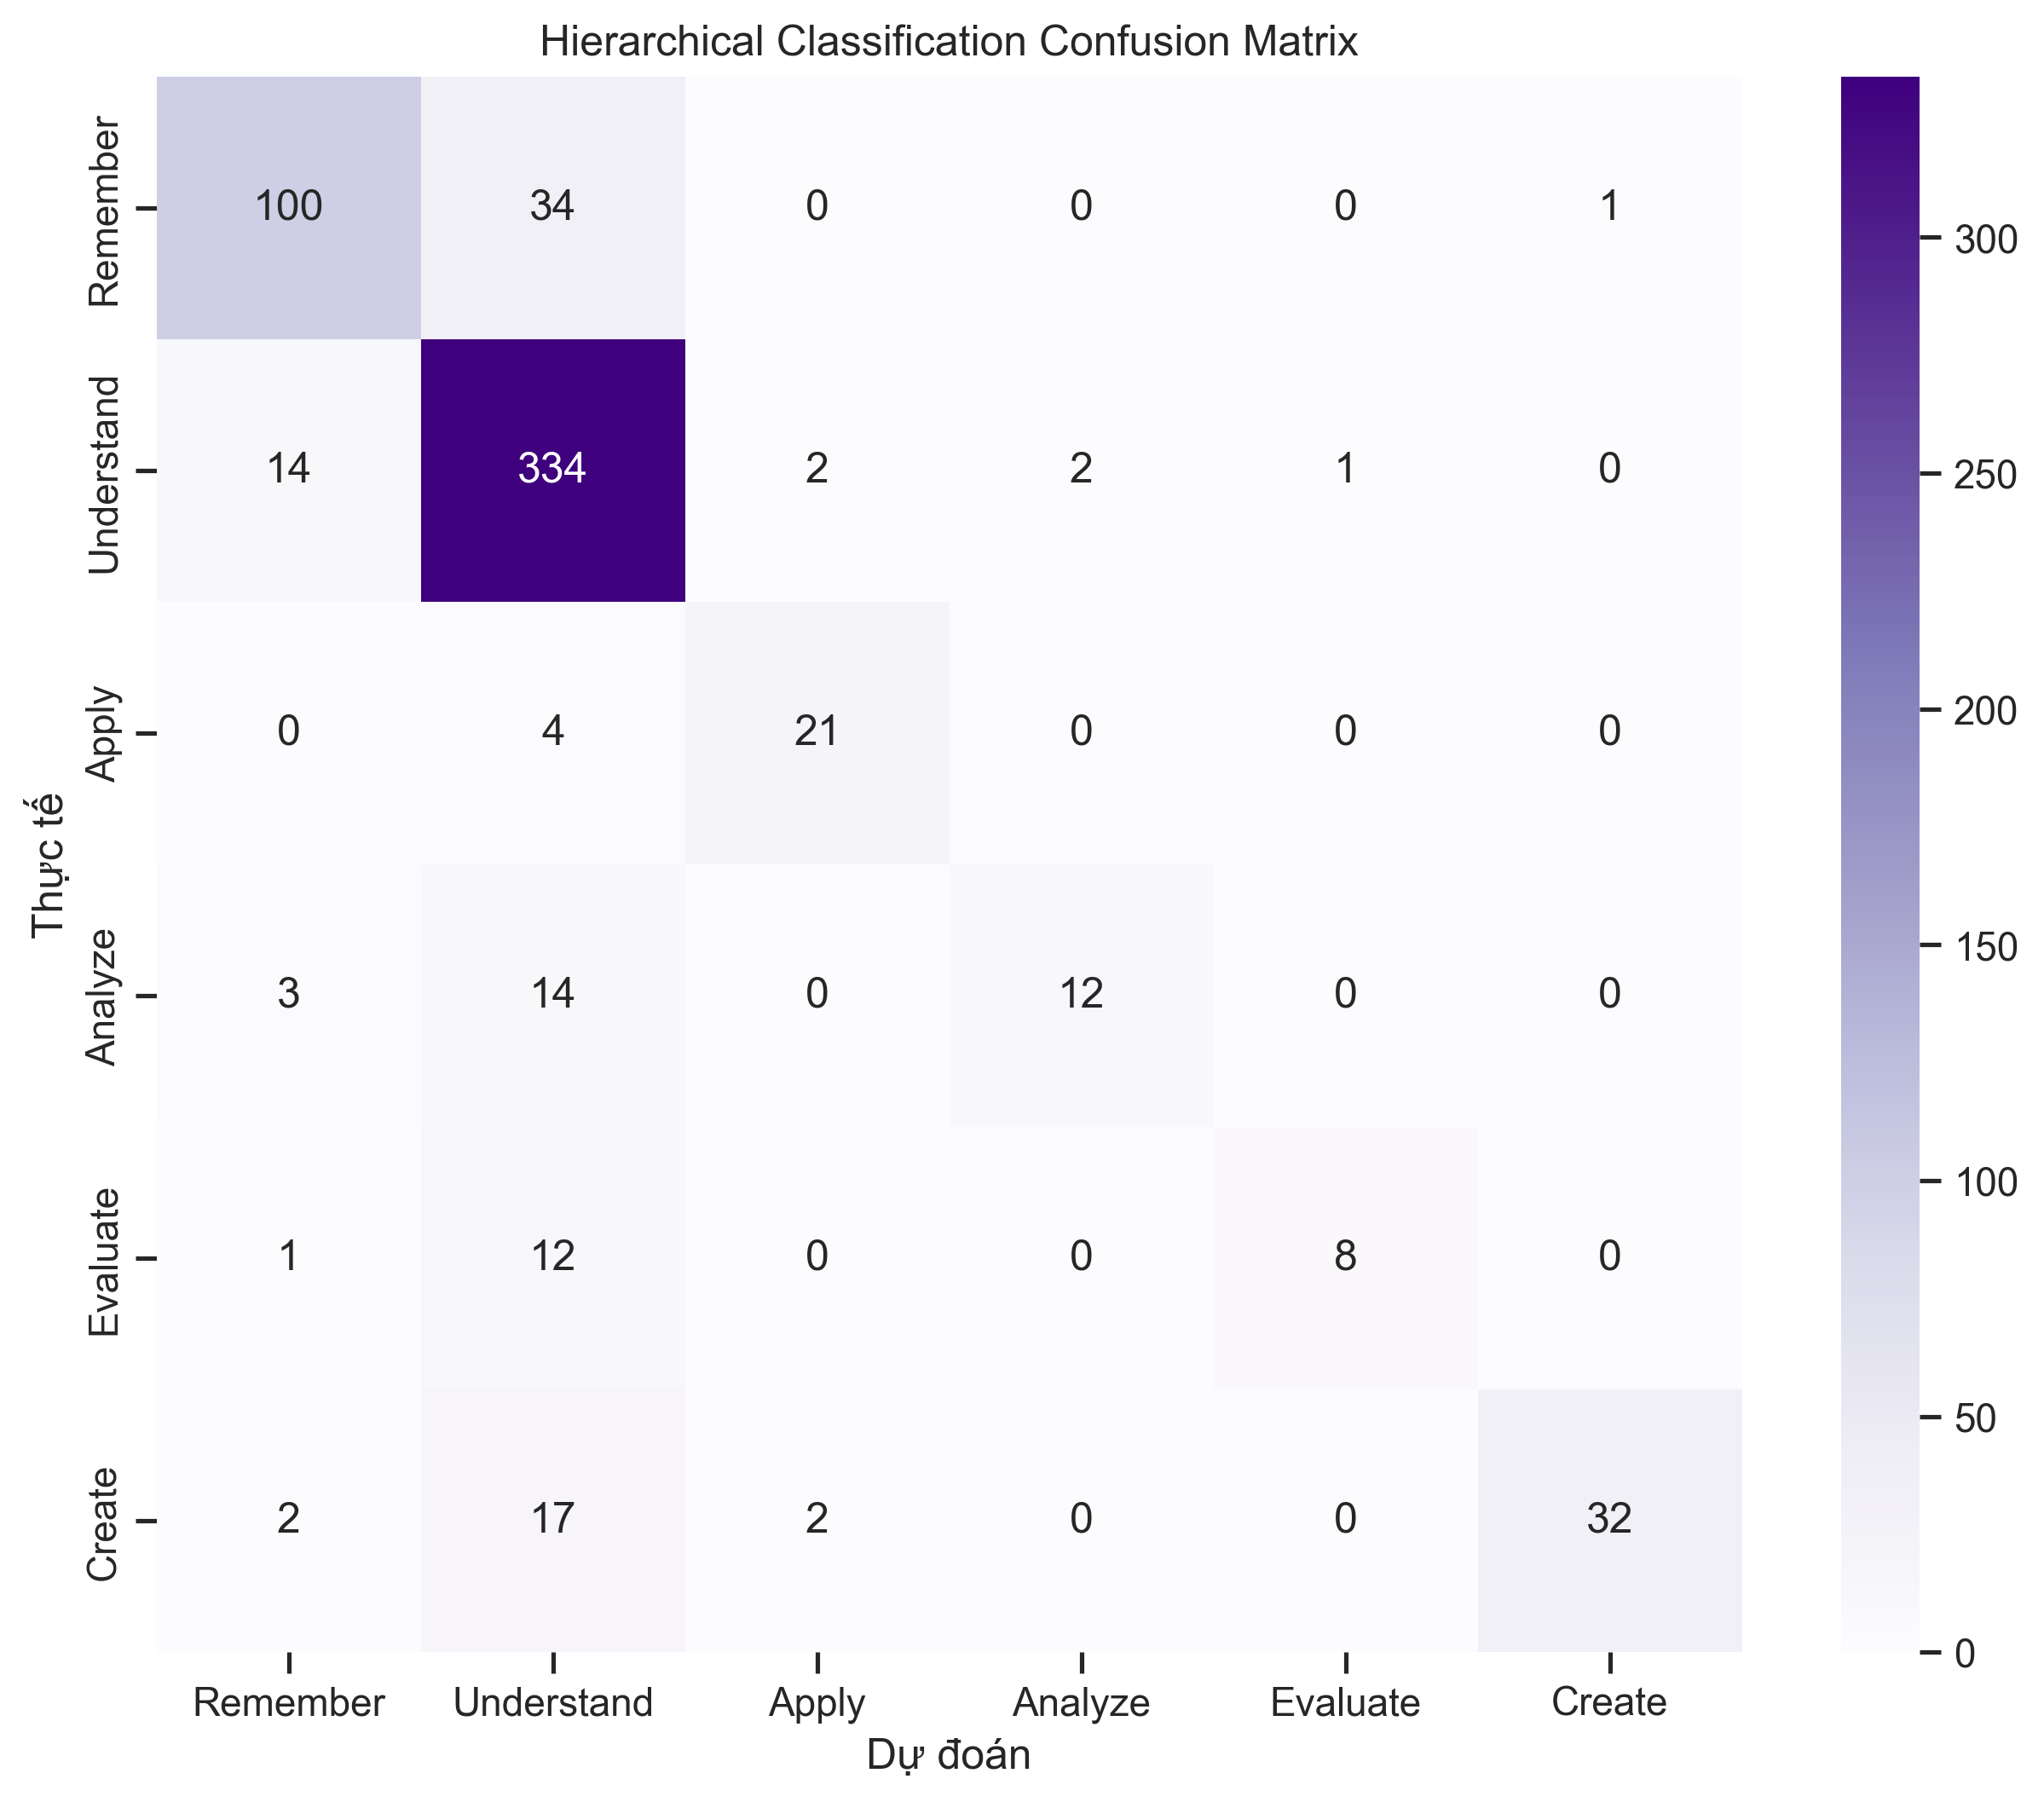

In [53]:
# ==========================================
# 3. HUẤN LUYỆN GIAI ĐOẠN 2: CÁC MODEL CON (SPECIALISTS)
# ==========================================

# --- 3.1 Model cho nhóm LOW (Remember, Understand) ---
print("\n🔹 [STAGE 2.1] Huấn luyện Low-Level Specialist...")
# Lọc dữ liệu Train chỉ thuộc nhóm Low
mask_low = y_train.isin(LOW_LEVELS)
X_train_low = X_train[mask_low]
y_train_low = y_train[mask_low]

# Encode nhãn cho nhóm Low
le_low = LabelEncoder()
y_train_low_enc = le_low.fit_transform(y_train_low)

# === SỬA LỖI TẠI ĐÂY ===
# Đếm số lượng lớp cụ thể (Ví dụ: Remember, Understand -> 2 lớp)
num_class_low = len(le_low.classes_) 

# Train model Low
model_low = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    objective='multi:softmax',
    num_class=num_class_low,  # <--- BẮT BUỘC PHẢI CÓ DÒNG NÀY
    eval_metric='mlogloss'
)
model_low.fit(X_train_low, y_train_low_enc)


# --- 3.2 Model cho nhóm HIGH (Apply, Analyze, Evaluate, Create) ---
print("🔸 [STAGE 2.2] Huấn luyện High-Level Specialist (có SMOTE)...")
# Lọc dữ liệu Train chỉ thuộc nhóm High
mask_high = y_train.isin(HIGH_LEVELS)
X_train_high = X_train[mask_high]
y_train_high = y_train[mask_high]

# Encode nhãn cho nhóm High
le_high = LabelEncoder()
y_train_high_enc = le_high.fit_transform(y_train_high)

# Cân bằng dữ liệu (SMOTE)
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_high_res, y_train_high_res = smote.fit_resample(X_train_high, y_train_high_enc)

# === SỬA LỖI TẠI ĐÂY ===
# Đếm số lượng lớp cụ thể (Ví dụ: 4 lớp)
num_class_high = len(le_high.classes_)

# Train model High
model_high = xgb.XGBClassifier(
    n_estimators=500,        # Tăng lên 500 cây
    max_depth=8,             # Tăng độ sâu lên 8 vì Create/Evaluate rất phức tạp
    learning_rate=0.05,
    random_state=42,
    objective='multi:softmax',
    num_class=num_class_high,
    eval_metric='mlogloss',
    # gamma=0.1,             # Thử thêm gamma để giảm overfitting nếu cần
    # min_child_weight=2
)
model_high.fit(X_train_high_res, y_train_high_res)
# ==========================================
# 4. HÀM DỰ ĐOÁN TỔNG HỢP (HIERARCHICAL PREDICTION)
# ==========================================
def hierarchical_predict(X_input):
    # Bước 1: Dự đoán Binary (0 hoặc 1)
    binary_preds = model_binary.predict(X_input)
    
    final_preds = []
    
    # Bước 2: Duyệt từng mẫu để đưa vào model con tương ứng
    # (Lưu ý: Có thể tối ưu vector hóa, nhưng dùng loop để dễ hiểu logic)
    for i, pred_bin in enumerate(binary_preds):
        # Lấy dòng dữ liệu hiện tại (reshape để đúng format model)
        row = X_input.iloc[[i]]
        
        if pred_bin == 0: # Nhóm Low
            sub_pred_enc = model_low.predict(row)[0]
            final_label = le_low.inverse_transform([sub_pred_enc])[0]
        else: # Nhóm High
            sub_pred_enc = model_high.predict(row)[0]
            final_label = le_high.inverse_transform([sub_pred_enc])[0]
            
        final_preds.append(final_label)
    return np.array(final_preds)

# ==========================================
# 5. ĐÁNH GIÁ KẾT QUẢ CUỐI CÙNG
# ==========================================
print("\n" + "="*30)
print("🧪 ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP")
print("="*30)

# Dự đoán toàn bộ tập Test
y_pred_final = hierarchical_predict(X_test)

# Tính metrics
acc = accuracy_score(y_test, y_pred_final)
print(f"✅ Final Accuracy: {acc:.4f}")
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred_final))

# Vẽ Confusion Matrix
plt.figure(figsize=(10, 8))
labels_order = LOW_LEVELS + HIGH_LEVELS # Sắp xếp thứ tự cho đẹp
cm = confusion_matrix(y_test, y_pred_final, labels=labels_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_order,
            yticklabels=labels_order)
plt.title('Hierarchical Classification Confusion Matrix')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()
        

In [54]:
!pip install xgboost
!pip install imbalanced-learn


🧠 2. GIẢI MÃ SHAP (ROBUST VERSION)

🅰️ [Chart A] High Levels Drivers...


<Figure size 3000x2100 with 0 Axes>

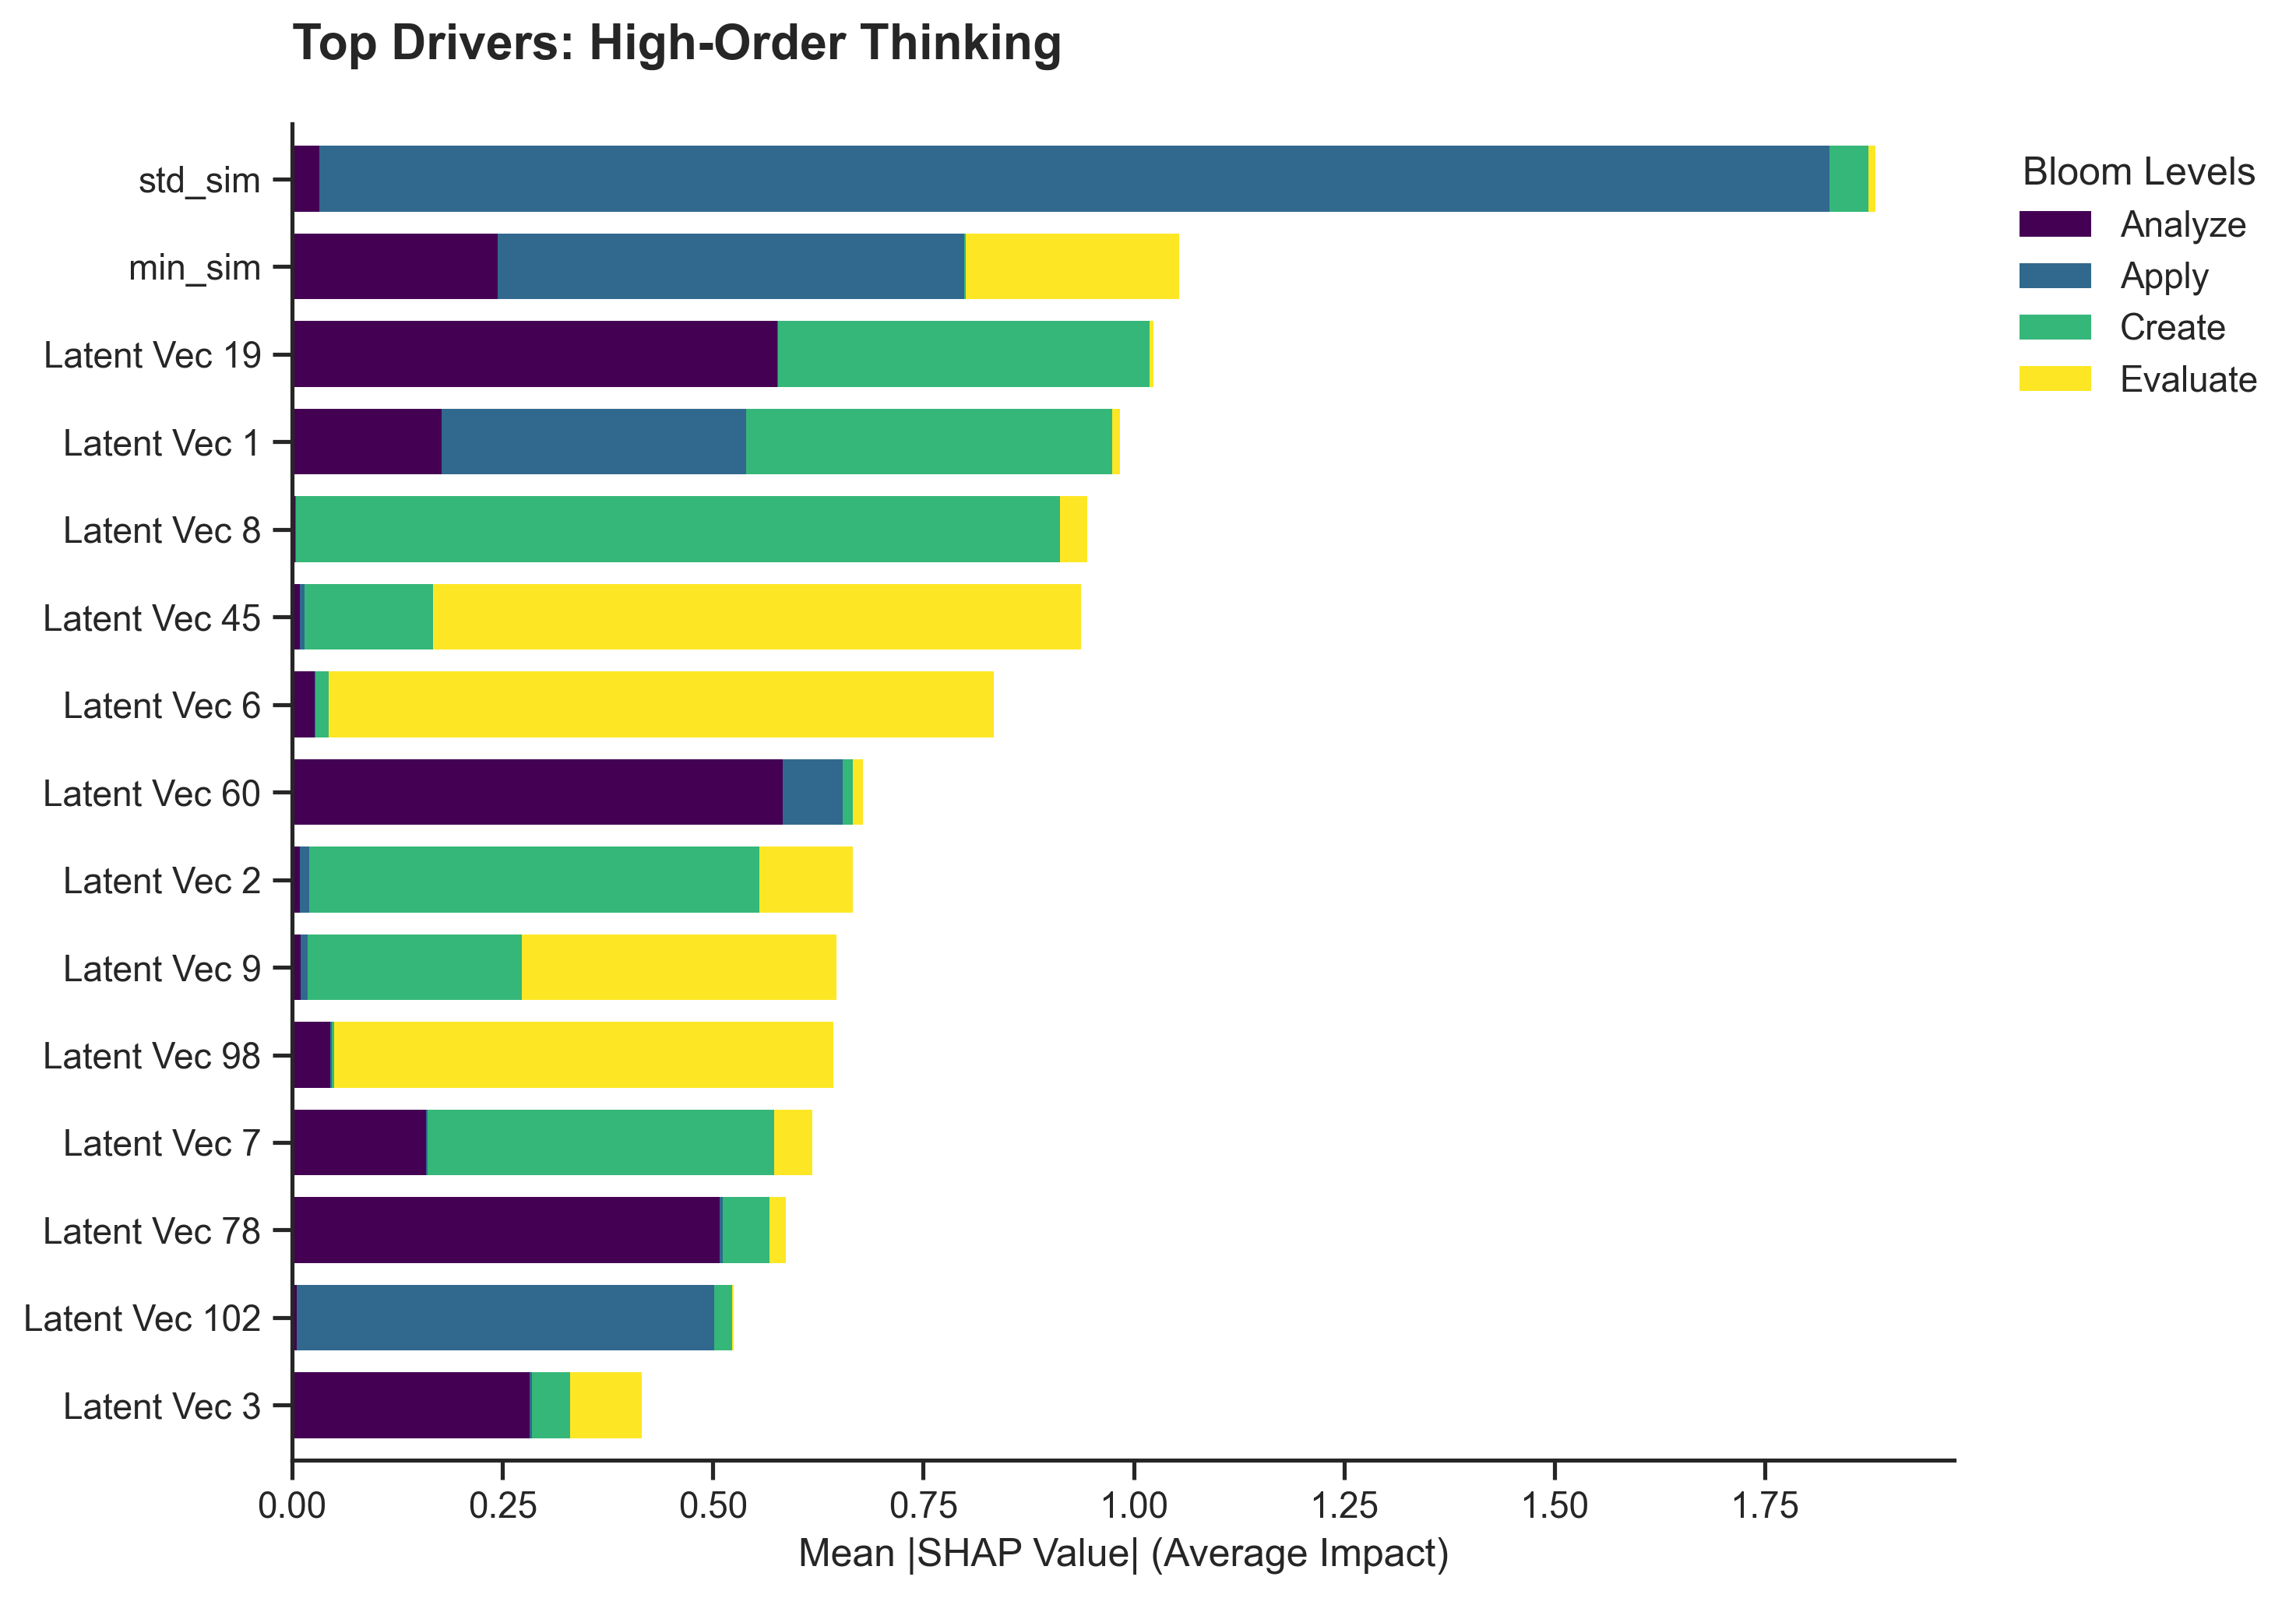


🅱️ [Chart B] Low Levels Drivers...


<Figure size 3000x2100 with 0 Axes>

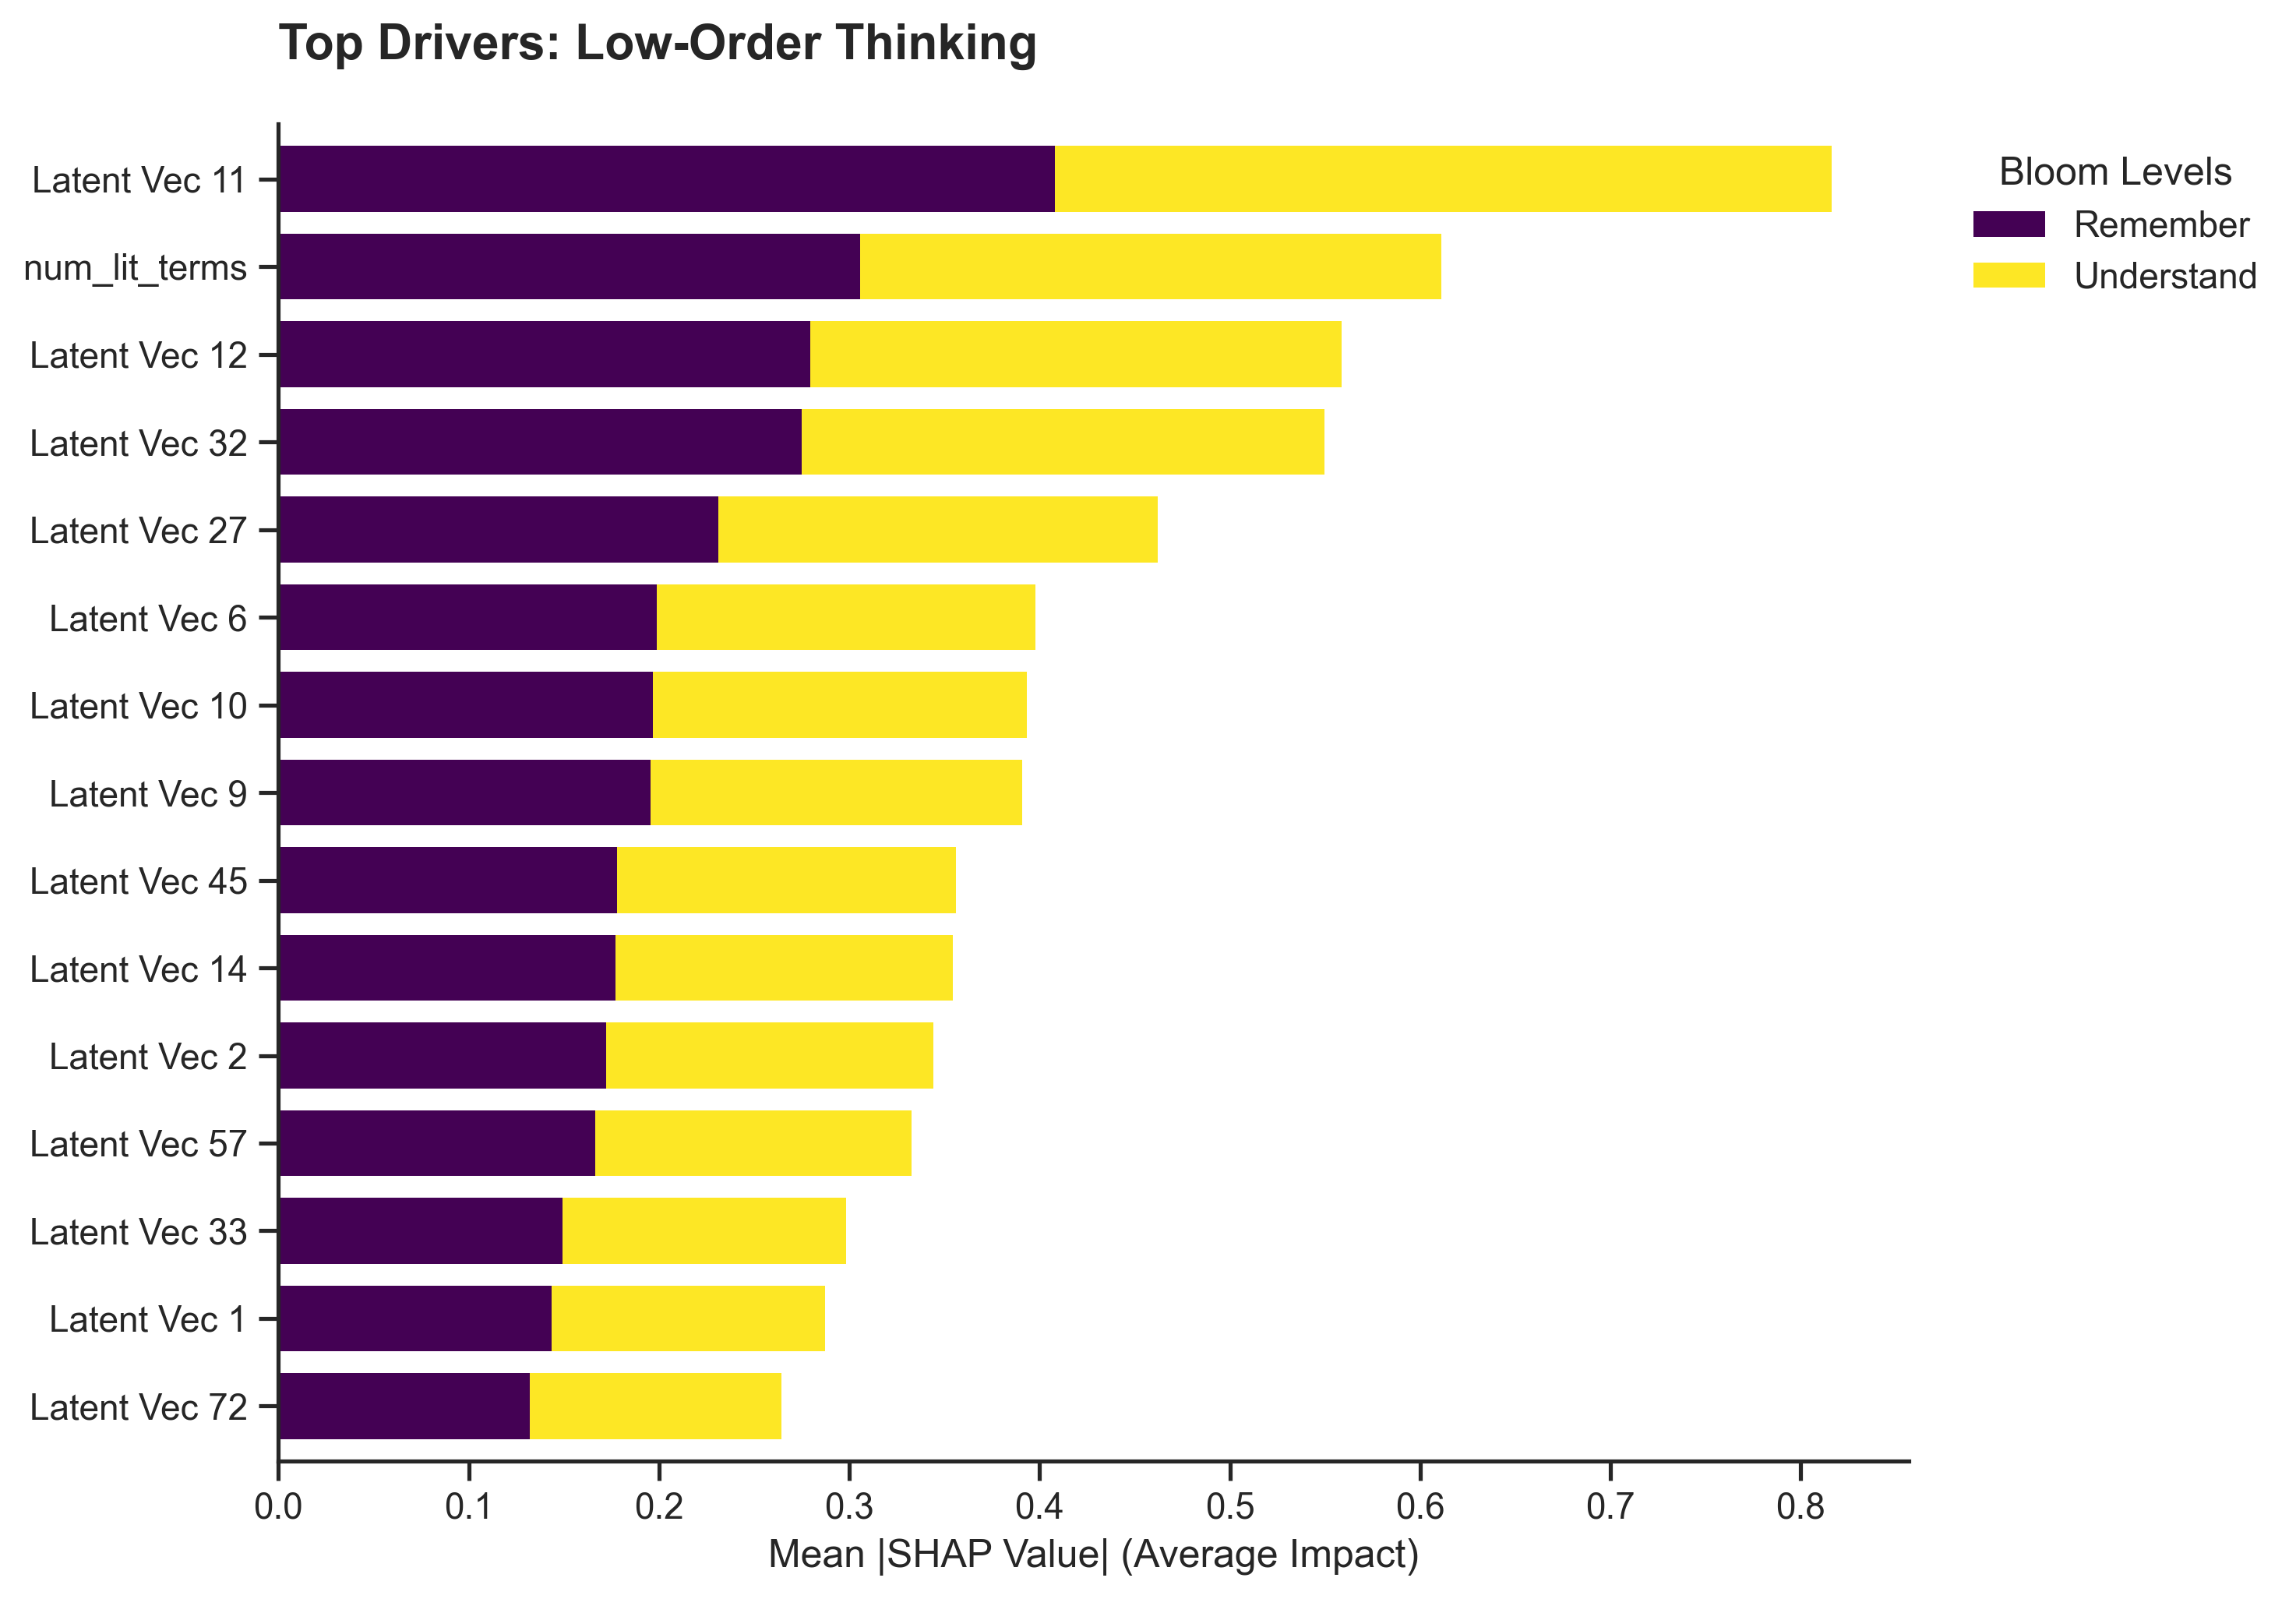


©️ [Chart C] Detailed Direction for 'Create'...


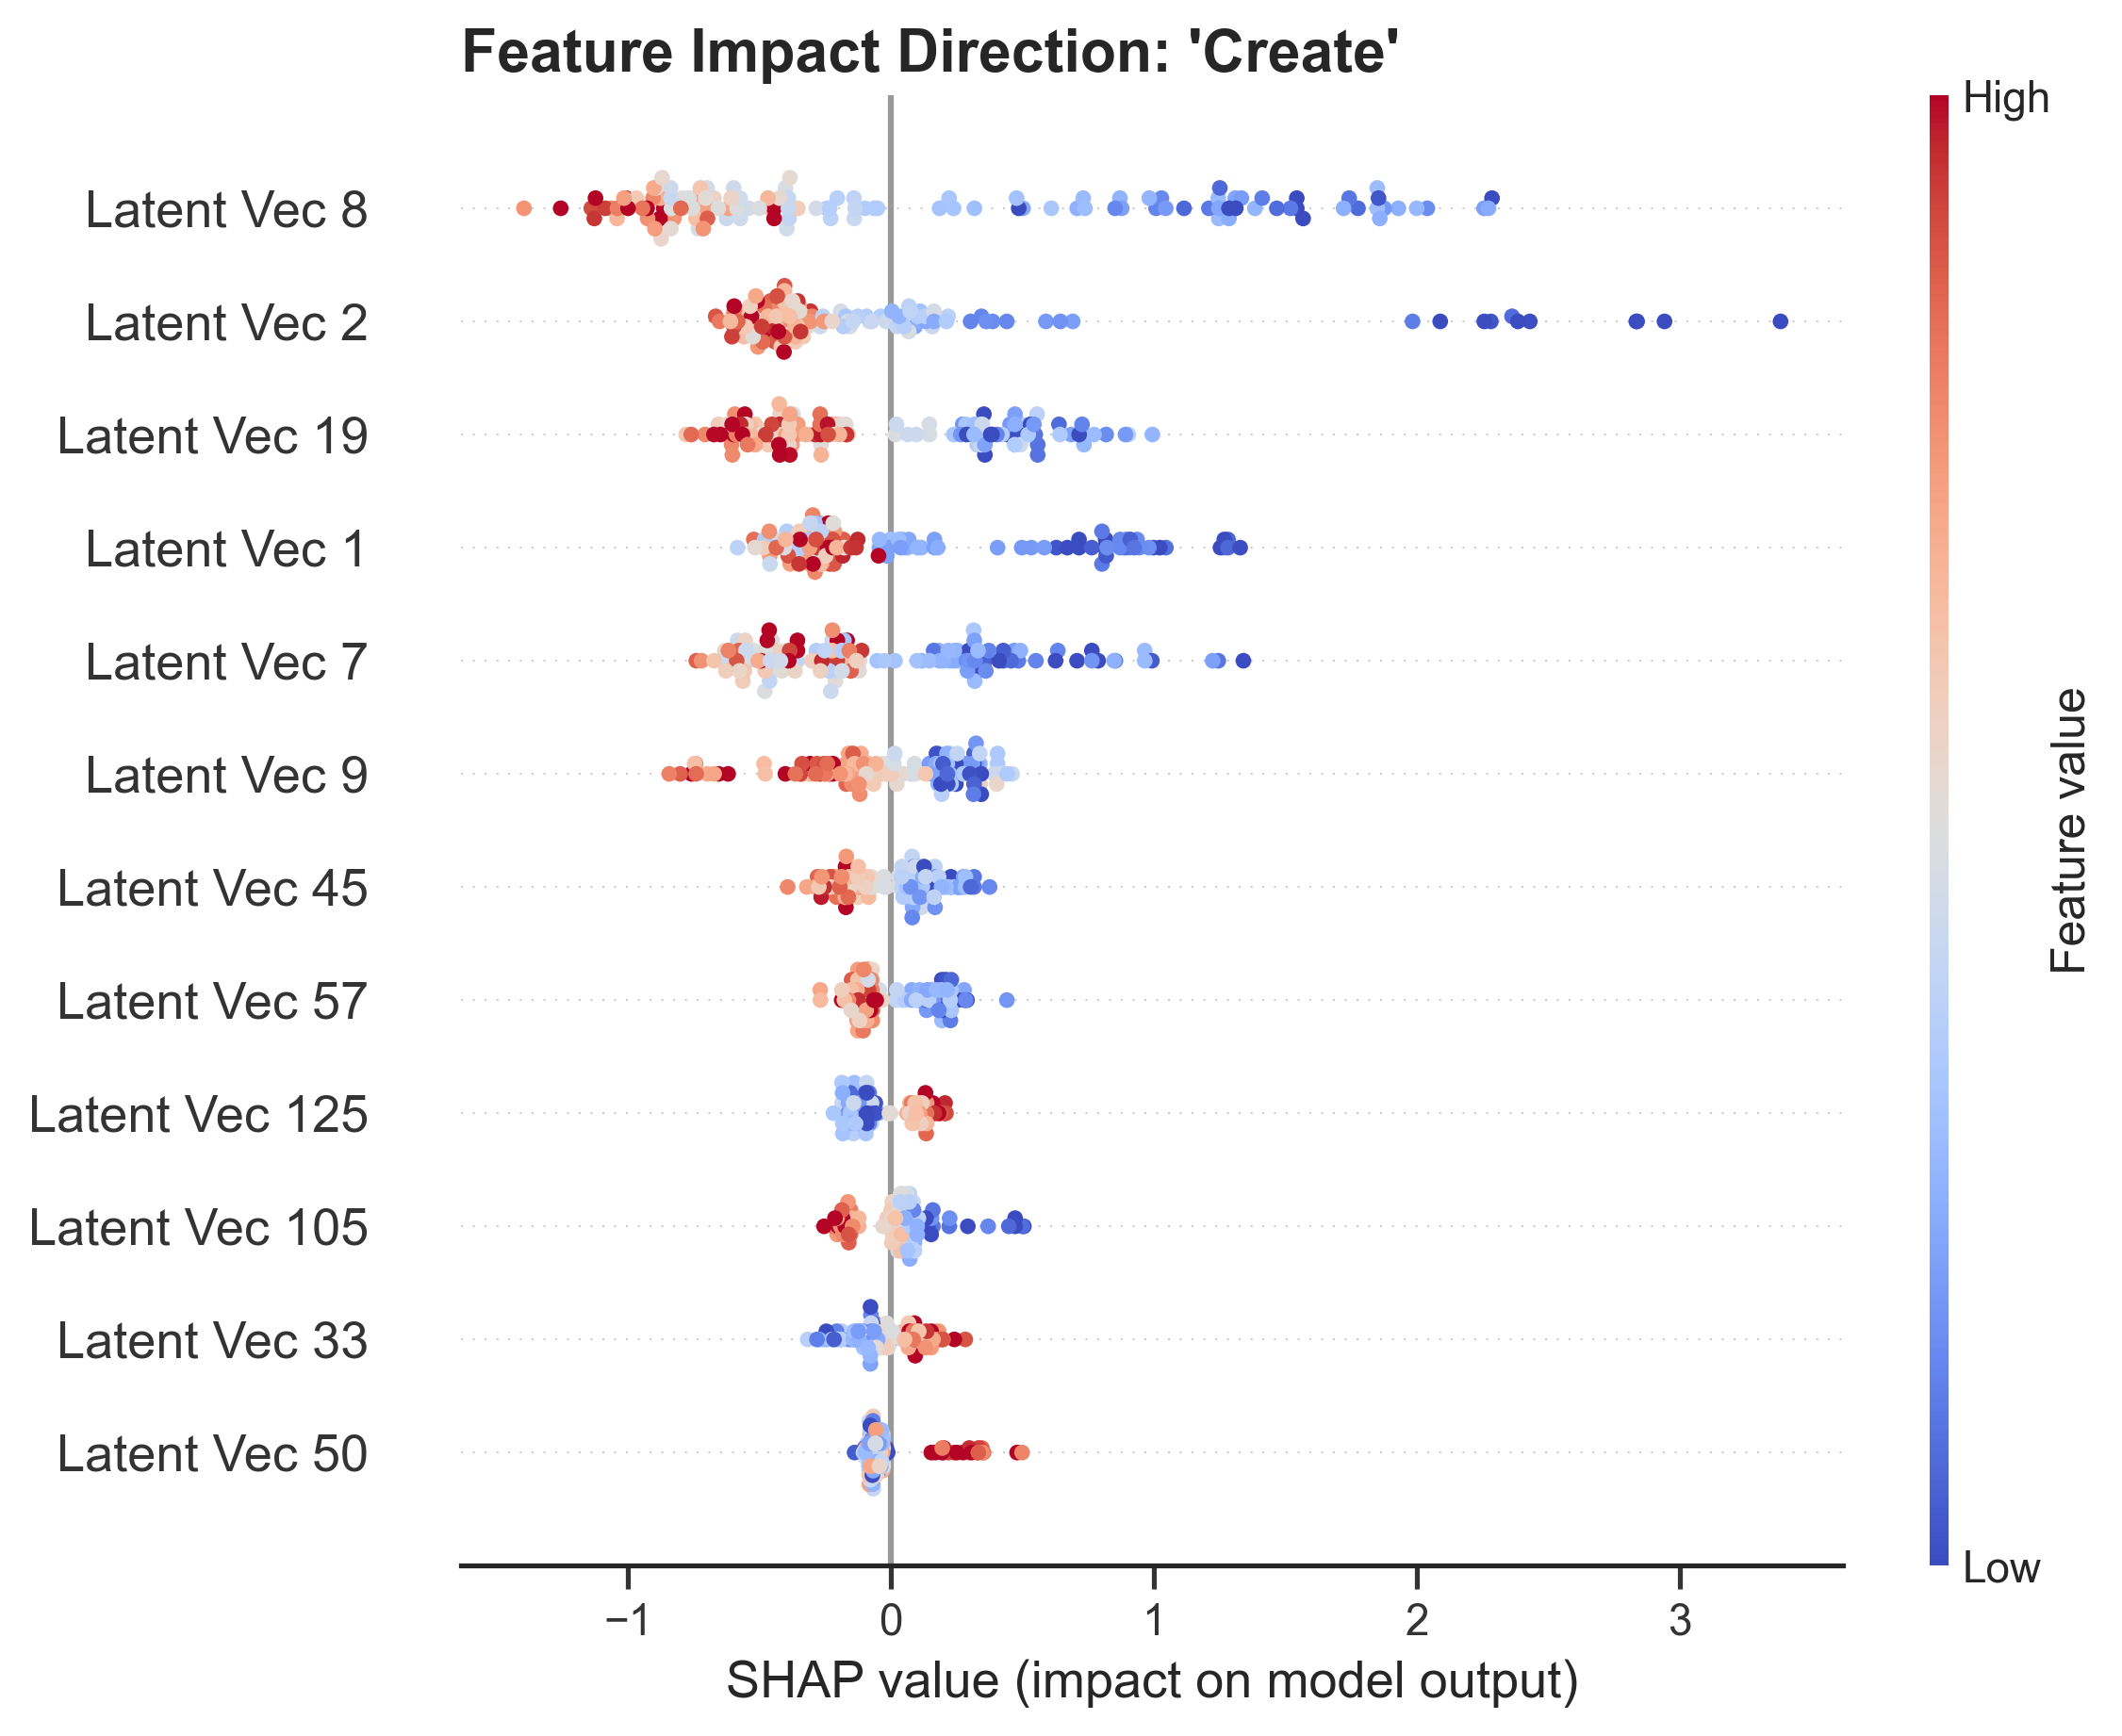

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import matplotlib.patches as mpatches

# ==============================================================================
# PHẦN 2: GIẢI MÃ SHAP (PHIÊN BẢN FIX LỖI SHAPE/DIMENSION)
# ==============================================================================
print("\n" + "="*40)
print("🧠 2. GIẢI MÃ SHAP (ROBUST VERSION)")
print("="*40)

# 1. CẤU HÌNH GIAO DIỆN
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 2. TỪ ĐIỂN ĐỔI TÊN FEATURE
feature_map = {
    'mean_sim': 'Semantic Similarity',
    'max_sim': 'Max Similarity',
    'mean_jaccard_sim': 'Lexical Overlap',
    'sentence_length': 'Sentence Length',
    'perplexity': 'Text Complexity (PPL)',
    'num_clauses': 'Clause Count',
    'num_verbs': 'Verb Count',
    'num_adjs': 'Adjective Count',
    'is_Compare': 'Type: Comparison',
    'is_Why': 'Type: Why-Question'
}

def beautify_feature_names(df, mapping):
    new_cols = []
    for col in df.columns:
        if col in mapping:
            new_cols.append(mapping[col])
        elif col.startswith('emb_'):
            new_cols.append(col.replace('emb_', 'Latent Vec '))
        else:
            new_cols.append(col)
    return new_cols

# --- HÀM CỐT LÕI: XỬ LÝ MA TRẬN SHAP AN TOÀN ---
def get_feature_importance_df(shap_values, X_data, class_names):
    """
    Hàm này tự động phát hiện SHAP là List hay 3D Array để xử lý đúng,
    tránh lỗi ValueError: Expected 1D array.
    """
    feature_names = beautify_feature_names(X_data, feature_map)
    df_imp = pd.DataFrame(index=feature_names)
    
    # DEBUG: In ra để kiểm soát nếu có lỗi
    # print(f"DEBUG: Processing SHAP for classes: {class_names}")
    
    for i, c_name in enumerate(class_names):
        sv = None
        
        # --- LOGIC 1: Trích xuất SHAP values cho đúng lớp thứ i ---
        
        # Trường hợp A: SHAP là List (thường gặp ở XGBoost Multiclass)
        if isinstance(shap_values, list):
            if i < len(shap_values):
                sv = shap_values[i]
            else:
                # Nếu thiếu (ví dụ Binary model chỉ trả về 1 array), dùng lại array cuối
                sv = shap_values[-1]
                
        # Trường hợp B: SHAP là Array 3 chiều (Samples, Features, Classes)
        elif len(shap_values.shape) == 3:
            # Kiểm tra xem chiều nào tương ứng với class (thường là chiều cuối)
            if shap_values.shape[2] == len(class_names):
                sv = shap_values[:, :, i]
            else:
                # Fallback hiếm gặp
                sv = shap_values[:, :, -1]

        # Trường hợp C: SHAP là Array 2 chiều (Binary - Samples, Features)
        elif len(shap_values.shape) == 2:
            sv = shap_values

        # --- LOGIC 2: Xử lý kích thước (Shape Mismatch) ---
        
        # Đảm bảo sv là 2D (Samples, Features)
        if len(sv.shape) == 3: 
            # Nếu vô tình vẫn còn 3D, cắt lấy lớp đầu tiên để không crash
            sv = sv[:, :, 0] 
            
        # Fix lỗi dư cột bias (Nếu số cột SHAP nhiều hơn số cột Data)
        if sv.shape[1] > len(feature_names):
            sv = sv[:, :len(feature_names)]
            
        # --- LOGIC 3: Tính Mean và Gán vào DataFrame ---
        
        # Tính trung bình độ tuyệt đối (Mean Absolute Impact)
        # Kết quả phải là mảng 1 chiều (chỉ chứa giá trị feature importance)
        mean_abs_shap = np.mean(np.abs(sv), axis=0)
        
        # Kiểm tra lần cuối: Nếu mean_abs_shap vẫn là ma trận (do lỗi shape input) -> Flatten nó
        if len(mean_abs_shap.shape) > 1:
            mean_abs_shap = np.mean(mean_abs_shap, axis=1) # Ép về 1 chiều

        # Gán vào cột tương ứng
        try:
            df_imp[c_name] = mean_abs_shap
        except Exception as e:
            print(f"⚠️ Bỏ qua lớp {c_name} do lỗi kích thước: {e}")
            continue

    # Tổng hợp và lấy Top 15
    df_imp['Total'] = df_imp.sum(axis=1)
    df_imp = df_imp.sort_values(by='Total', ascending=True).tail(15)
    return df_imp.drop(columns=['Total'])

# --- HÀM VẼ BIỂU ĐỒ STACKED BAR ---
def plot_manual_stacked_bar(model, X_data, le_encoder, title, cmap_name='viridis'):
    # Lấy mẫu
    if len(X_data) > 200: 
        X_sample = X_data.sample(200, random_state=42)
    else: 
        X_sample = X_data
        
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    class_names = list(le_encoder.classes_)
    
    # Tính toán Dataframe an toàn
    df_plot = get_feature_importance_df(shap_values, X_sample, class_names)
    
    # VẼ BẰNG PANDAS
    plt.figure(figsize=(10, 7))
    ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 7), 
                      colormap=cmap_name, width=0.75, edgecolor='none')
    
    # Trang trí
    plt.title(title, fontsize=15, fontweight='bold', loc='left', pad=20)
    plt.xlabel('Mean |SHAP Value| (Average Impact)', fontsize=12)
    plt.yticks(fontsize=11)
    
    # Legend đẹp
    plt.legend(title="Bloom Levels", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

# --- THỰC THI VẼ 3 BIỂU ĐỒ ---

# 1. CHART A: HIGH LEVELS
print("\n🅰️ [Chart A] High Levels Drivers...")
mask_high = y_test.isin(HIGH_LEVELS)
plot_manual_stacked_bar(
    model=model_high,
    X_data=X_test[mask_high],
    le_encoder=le_high,
    title="Top Drivers: High-Order Thinking",
    cmap_name="viridis"
)

# 2. CHART B: LOW LEVELS
print("\n🅱️ [Chart B] Low Levels Drivers...")
mask_low = y_test.isin(LOW_LEVELS)
plot_manual_stacked_bar(
    model=model_low,
    X_data=X_test[mask_low],
    le_encoder=le_low,
    title="Top Drivers: Low-Order Thinking",
    cmap_name="viridis" 
)

# 3. CHART C: CHI TIẾT LỚP CREATE (BEESWARM)
print("\n©️ [Chart C] Detailed Direction for 'Create'...")
target_class = "Create"
if target_class in le_high.classes_:
    X_high = X_test[mask_high]
    if len(X_high) > 200: X_high = X_high.sample(200, random_state=42)
    
    X_disp = pd.DataFrame(X_high.values, columns=beautify_feature_names(X_high, feature_map))
    
    explainer = shap.TreeExplainer(model_high)
    shap_vals = explainer.shap_values(X_high)
    
    idx = list(le_high.classes_).index(target_class)
    
    # Lấy đúng array cho lớp Create
    if isinstance(shap_vals, list):
        sv = shap_vals[idx]
    elif len(shap_vals.shape) == 3:
        sv = shap_vals[:, :, idx]
    else:
        sv = shap_vals
        
    # Fix bias
    if sv.shape[1] != X_disp.shape[1]: sv = sv[:, :X_disp.shape[1]]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_disp, max_display=12, show=False, cmap="coolwarm")
    plt.title(f"Feature Impact Direction: '{target_class}'", fontsize=15, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()